In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np



In [4]:
# to load the dataset 
df = pd.read_csv('../Data/nova_pay_combined.csv')
df.head()


,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [49]:
# Check for missing values 
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   300
fee                          290
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   300
ip_country                   296
location_mismatch              0
ip_risk_score                  0
kyc_tier                     295
account_age_days               0
device_trust_score           290
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [50]:
#Percentage of the missing values 
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0]

timestamp             0.258929
amount_usd            2.678571
fee                   2.589286
ip_address            2.678571
ip_country            2.642857
kyc_tier              2.633929
device_trust_score    2.589286
dtype: float64

In [ ]:
#Missing Numerical values data
missing_numeric = [
    'amount_usd',
    'fee',
    'device_trust_score'
]

In [52]:
#Missing category data
categorical_missing = [
    'ip_address',
    'ip_country',
    'kyc_tier'
]

In [ ]:
# Handle missing value in Amount_usd
df['amount_usd'].describe()

count    10900.000000
mean       451.710904
std       1401.028359
min          7.230000
25%         92.492500
50%        163.485000
75%        302.707500
max      12498.570000
Name: amount_usd, dtype: float64

In [105]:
# check the data type of amount_usd
df['amount_usd'].dtype

# filling the missing value in amount_usd
df['amount_usd'] = df['amount_usd'].fillna(df['amount_usd'].median())

#check again after filling 
df['amount_usd'].isnull().sum()

np.int64(0)

In [106]:
# filling missing values in fees 
df['fee'] = df['fee'].fillna(df['fee'].median())

df['fee'].isnull().sum()

np.int64(0)

In [107]:
# handle missing values for device_trust_score
df['device_trust_score'] = df['device_trust_score'].fillna(
    df['device_trust_score'].median()
)

df['device_trust_score'].isnull().sum()

np.int64(0)

In [108]:
#Handle missing values for ip_address
df['ip_address'] = df['ip_address'].fillna('Unknown')
df['ip_address'].isnull().sum()


np.int64(0)

In [109]:
# Handle missing values for ip_country
df['ip_country'] = df['ip_country'].fillna('Unknown')
df['ip_country'].isnull().sum()

np.int64(0)

In [110]:
#Handle missing value for kyc_tier
df['kyc_tier'] = df['kyc_tier'].fillna('Unknown')
df['kyc_tier'].isnull().sum()

np.int64(0)

In [95]:
# to check the total sum of missing values in timestamp
df['timestamp'].isnull().sum()

np.int64(61)

In [111]:
# to check the data type 
df['timestamp'].dtype

#inspect the missing values
df[df['timestamp'].isna()]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud


In [99]:
#to check if the missing stamp are actually missing 
df[df['timestamp'].isna()].isnull().sum(axis=1).value_counts()

len(df)

11400

In [102]:
#to remove rows with missing values 
df = df.dropna(subset=['timestamp'])

#to check 
df['timestamp'].isnull().sum()

len(df)

11339

In [115]:
df[['timestamp','amount_usd', 'fee', 'ip_address', 'ip_country', 'kyc_tier', 'device_trust_score']].isnull().sum()

timestamp             0
amount_usd            0
fee                   0
ip_address            0
ip_country            0
kyc_tier              0
device_trust_score    0
dtype: int64

In [114]:
df.isnull().sum().sum()

df.shape

(11339, 26)

In [ ]:
df.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='str')

In [7]:
df.shape 

(11400, 26)

In [ ]:
# To check the few rows of the duplicated rows
df[df.duplicated()].head()


,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
10000,a5a4d5fc-f8df-4fa9-9ac6-36d3c4e3f1bb,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,2024-10-21 18:24:40.468549+00:00,UK,GBP,CNY,mobile,79.41,99.26,1.78,...,0.127,standard,4,0.892,0,0.407,6,6,0.0,0
10001,88dd45c3-38b9-498f-a767-0fc20c598a89,af8ca4c4-8703-4c55-b66c-2b76cd70040d,2023-08-29 10:22:29.468549+00:00,US,USD,GBP,mobile,-320.4,320.40,9999.99,...,1.200,standard,1018,-0.100,0,0.087,-1,0,0.0,0
10002,0de01bd2-638e-4c0d-800f-16c4528351de,d71c91b4-fee8-4104-9856-a5c6109a62e3,2025-08-25 11:42:34.468549+00:00,US,USD,USD,web,96.37,96.37,2.65,...,0.487,standard,298,0.336,0,0.166,0,0,0.0,0
10003,8f3264ec-53af-47ad-bf98-b870d9956173,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2025-09-04 08:07:31.468549+00:00,US,USD,GBP,ATM,53.16,53.16,1.66,...,0.405,enhanced,257,0.894,0,0.257,0,0,0.0,0
10004,a301be5c-bf14-411a-a201-3abf74de8a7e,402cccc9-28de-45b3-9af7-cc5302aa1f93,2025-01-27 15:05:01.468549+00:00,US,USD,USD,web,119.97,119.97,2.76,...,0.494,standard,263,0.522,0,0.223,0,0,0.0,0


In [119]:
#To remove exact duplicates
df = df.drop_duplicates()

In [120]:
#to check if the duplicates are gone 
df.duplicated().sum()


np.int64(0)

In [121]:
# to check the size of a data set 
df.shape

(11140, 26)

In [122]:
#To check for duplicate transaction IDs
df['transaction_id'].duplicated().sum()

np.int64(0)

In [123]:
#to verify everything again 
df.info()

<class 'pandas.DataFrame'>
Index: 11140 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             11140 non-null  str                
 1   customer_id                11140 non-null  str                
 2   timestamp                  11140 non-null  datetime64[us, UTC]
 3   home_country               11140 non-null  str                
 4   source_currency            11140 non-null  str                
 5   dest_currency              11140 non-null  str                
 6   channel                    11140 non-null  str                
 7   amount_src                 11140 non-null  str                
 8   amount_usd                 11140 non-null  float64            
 9   fee                        11140 non-null  float64            
 10  exchange_rate_src_to_dest  11140 non-null  float64            
 11  device_id         

In [124]:
# to show how many fraudulent vs non-fraudulent transactions
df['is_fraud'].value_counts()

is_fraud
0    10147
1      993
Name: count, dtype: int64

In [125]:
#To show the columns in numerical data
df.select_dtypes(include='number').columns

Index(['amount_usd', 'fee', 'exchange_rate_src_to_dest', 'ip_risk_score',
       'account_age_days', 'device_trust_score', 'chargeback_history_count',
       'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h',
       'corridor_risk', 'is_fraud'],
      dtype='str')

In [126]:
# to check for outliers we will investigate the numerical columns (1. amount_usd)
# to check for basic stat in amount_usd 
df['amount_usd'].describe()


count    11140.000000
mean       443.487897
std       1380.522475
min          7.230000
25%         94.340000
50%        163.645000
75%        296.635000
max      12498.570000
Name: amount_usd, dtype: float64

In [ ]:
# To calculate the IQR( to test if they are truly outliers) for amount_usd
Q1 = df['amount_usd'].quantile(0.25)
Q3 = df['amount_usd'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 94.34
Q3: 296.635
IQR: 202.295
Lower bound: -209.1025
Upper bound: 600.0775


In [128]:
#to find out how many outliers 
amount_outliers = df[df['amount_usd'] > upper_bound]

len(amount_outliers)

1059

In [129]:
#to inspect the outlier 
amount_outliers['amount_usd'].describe()

count     1059.000000
mean      2927.231870
std       3618.163942
min        602.040000
25%        732.835000
50%       1068.990000
75%       2558.940000
max      12498.570000
Name: amount_usd, dtype: float64

In [130]:
#to see if the high value are actually associated with fraud
amount_outliers['is_fraud'].value_counts()

is_fraud
0    591
1    468
Name: count, dtype: int64

In [131]:
#to check largest transaction 
df.nlargest(10, 'amount_usd')[['amount_usd', 'is_fraud']]

,amount_usd,is_fraud
4812,12498.57,0
6166,12497.90,0
624,12497.19,0
9426,12497.00,0
1967,12496.79,0
3988,12496.24,1
7546,12495.74,0
1333,12495.59,0
4479,12495.20,0
9430,12495.14,0


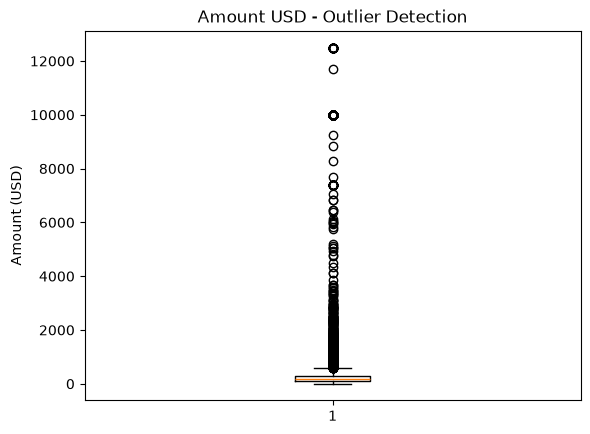

In [153]:
# to visualize outliers in amount_usd 
import matplotlib.pyplot as plt

plt.boxplot(df['amount_usd'])
plt.ylabel('Amount (USD)')
plt.title('Amount USD - Outlier Detection')
plt.show()

In [155]:
#identify the outliers 
amount_outliers = df[df['amount_usd'] > 600.08]

In [ ]:
#inspect the outliers
amount_outliers[['amount_usd', 'is_fraud']].describe()

,amount_usd,is_fraud
count,1059.000000,1059.000000
mean,2927.231870,0.441926
std,3618.163942,0.496851
min,602.040000,0.000000
25%,732.835000,0.000000
50%,1068.990000,0.000000
75%,2558.940000,1.000000
max,12498.570000,1.000000


In [156]:
#to see if the transactions is normal 
amount_outliers[['amount_usd', 'is_fraud']].head(20)

,amount_usd,is_fraud
11,9998.43,0
15,9991.85,0
52,1071.92,0
53,7398.00,0
55,1156.74,0
62,624.70,0
88,9993.40,0
90,1218.10,0
99,766.16,0
116,1542.34,0


In [132]:
# to check for outliers we will investigate the numerical columns (2. fee)
df['fee'].describe()

count    11140.000000
mean        97.205472
std        942.740829
min         -1.000000
25%          2.410000
50%          3.500000
75%          5.470000
max       9999.990000
Name: fee, dtype: float64

In [133]:
# To calculate the IQR( to test if they are truly outliers) for fee
Q1_fee = df['fee'].quantile(0.25)
Q3_fee = df['fee'].quantile(0.75)

IQR_fee = Q3_fee - Q1_fee

lower_bound_fee = Q1_fee - 1.5 * IQR_fee
upper_bound_fee = Q3_fee + 1.5 * IQR_fee

print("Q1:", Q1_fee)
print("Q3:", Q3_fee)
print("IQR:", IQR_fee)
print("Lower bound:", lower_bound_fee)
print("Upper bound:", upper_bound_fee)

Q1: 2.41
Q3: 5.47
IQR: 3.0599999999999996
Lower bound: -2.1799999999999997
Upper bound: 10.059999999999999


In [134]:
# how many outliers in fee
fee_outliers = df[df['fee'] > upper_bound_fee]

len(fee_outliers)

1099

In [135]:
#basics of the outliers
fee_outliers['fee'].describe()

count    1099.000000
mean      951.658007
std      2864.529848
min        10.060000
25%        12.860000
50%        19.220000
75%       150.345000
max      9999.990000
Name: fee, dtype: float64

In [136]:
#to check if they are associated with fraud 
fee_outliers['is_fraud'].value_counts()


is_fraud
0    626
1    473
Name: count, dtype: int64

In [137]:
# to show 10 largest fees 
df.nlargest(10, 'fee')[['fee', 'amount_usd', 'is_fraud']]

,fee,amount_usd,is_fraud
328,9999.99,37.080,0
564,9999.99,176.920,0
576,9999.99,702.710,0
596,9999.99,230.360,0
602,9999.99,150.830,0
655,9999.99,82.800,0
788,9999.99,143.130,0
798,9999.99,211.200,0
1311,9999.99,163.645,0
1418,9999.99,504.710,0


In [24]:
df.nunique()

transaction_id               11200
customer_id                   1315
timestamp                    11141
home_country                     7
source_currency                  3
dest_currency                    9
channel                         12
amount_src                    9856
amount_usd                    9621
fee                           1676
exchange_rate_src_to_dest       25
device_id                     2113
new_device                       2
ip_address                   10900
ip_country                       9
location_mismatch                2
ip_risk_score                  952
kyc_tier                        14
account_age_days               412
device_trust_score             677
chargeback_history_count         3
risk_score_internal            651
txn_velocity_1h                 10
txn_velocity_24h                12
corridor_risk                    7
is_fraud                         2
dtype: int64

In [26]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
amount_usd,10900.0,451.710904,1401.028359,7.230,92.4925,163.485000,302.707500,12498.570000
fee,10910.0,99.212001,952.526927,-1.000,2.3800,3.500000,5.560000,9999.990000
exchange_rate_src_to_dest,11200.0,167.453693,381.930143,0.592,1.0000,7.142857,73.529412,1388.888889
ip_risk_score,11200.0,0.397541,0.271213,0.004,0.2090,0.325000,0.488000,1.200000
account_age_days,11200.0,392.848571,342.123998,1.000,147.0000,293.000000,661.000000,1095.000000
device_trust_score,10910.0,0.653238,0.273174,-0.100,0.5150,0.654500,0.894000,0.999000
chargeback_history_count,11200.0,0.049375,0.258388,0.000,0.0000,0.000000,0.000000,2.000000
risk_score_internal,11200.0,0.267653,0.143521,0.000,0.1690,0.223000,0.391000,0.900000
txn_velocity_1h,11200.0,0.463839,1.532671,-1.000,0.0000,0.000000,0.000000,8.000000
txn_velocity_24h,11200.0,0.732411,1.970835,0.000,0.0000,0.000000,0.000000,11.000000


In [43]:
# to check for data types 
df.dtypes

transaction_id                   str
customer_id                      str
timestamp                        str
home_country                     str
source_currency                  str
dest_currency                    str
channel                          str
amount_src                       str
amount_usd                   float64
fee                          float64
exchange_rate_src_to_dest    float64
device_id                        str
new_device                      bool
ip_address                       str
ip_country                       str
location_mismatch               bool
ip_risk_score                float64
kyc_tier                         str
account_age_days               int64
device_trust_score           float64
chargeback_history_count       int64
risk_score_internal          float64
txn_velocity_1h                int64
txn_velocity_24h               int64
corridor_risk                float64
is_fraud                       int64
dtype: object

In [48]:
import re
from spellchecker import SpellChecker

spell = SpellChecker()

known_terms = [
    "US", "UK", "CA", "USD", "GBP", "CAD", "EUR", "MXN", "NGN",
    "INR", "CNY", "PHP", "ATM", "KYC", "unknown", "nan",
    "mobile", "web", "standard", "enhanced", "low"
]

spell.word_frequency.load_words(known_terms)

categorical_columns = [
    column for column in df.select_dtypes(include=["object", "string"]).columns
    if df[column].nunique(dropna=True) <= 100
]

incorrect_values_by_column = {}

for column in categorical_columns:
    incorrect_values = []

    for value in df[column].dropna().unique():
        words = re.findall(r"[A-Za-z]+", str(value))

        if spell.unknown(words):
            incorrect_values.append(value)

    if incorrect_values:
        incorrect_values_by_column[column] = incorrect_values

if incorrect_values_by_column:
    display(pd.DataFrame({
        column: pd.Series(values)
        for column, values in incorrect_values_by_column.items()
    }))
else:
    print("No misspelled values found.")

,channel,kyc_tier
0,mobille,standrd
1,weeb,enhancd
